# 📊 Day 12 — Exploratory Data Analysis (EDA)
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ What is EDA  
2️⃣ Why EDA Matters  
3️⃣ Step 1 — Loading the Dataset  
4️⃣ Step 2 — Understanding the Data  
5️⃣ Step 3 — Missing Values  
6️⃣ Step 4 — Univariate Analysis  
7️⃣ Step 5 — Bivariate Analysis  
8️⃣ Step 6 — Multivariate Analysis  
9️⃣ Step 7 — Outlier Detection  
🔟 When to Use What  

---
## 1️⃣ What is EDA?

Exploratory Data Analysis (EDA) is the process of **investigating a dataset** to understand its structure, patterns, and relationships before building any model.

EDA helps you answer:
- What does the data look like?
- Are there missing values?
- Are there outliers?
- What relationships exist between variables?

---
## 2️⃣ Why EDA Matters?

| Without EDA | With EDA |
|-------------|----------|
| Hidden missing values break your model | You catch and handle them early |
| Outliers skew predictions | You detect and decide how to treat them |
| Wrong assumptions about data | You understand distributions first |
| Poor feature selection | You know which variables actually matter |
| Unexplained model errors | You already saw the patterns in data |

---
## 3️⃣ Step 1 — Loading the Dataset

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Loading the Winemag dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


---
## 4️⃣ Step 2 — Understanding the Data

Before doing anything, we need to understand what we are working with.

In [4]:
# Shape of the dataset
df.shape

(129971, 13)

In [5]:
# Column names
df.columns.tolist()

['country',
 'description',
 'designation',
 'points',
 'price',
 'province',
 'region_1',
 'region_2',
 'taster_name',
 'taster_twitter_handle',
 'title',
 'variety',
 'winery']

In [6]:
# Data types of each column
df.dtypes

country                   object
description               object
designation               object
points                     int64
price                    float64
province                  object
region_1                  object
region_2                  object
taster_name               object
taster_twitter_handle     object
title                     object
variety                   object
winery                    object
dtype: object

In [7]:
# Statistical summary of numerical columns
df.describe()

,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000


In [8]:
# Statistical summary of categorical columns
df.describe(include='object')

,country,description,designation,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
count,129908,129971,92506,129908,108724,50511,103727,98758,129971,129970,129971
unique,43,119955,37979,425,1229,17,19,15,118840,707,16757
top,US,"Seductively tart in lemon pith, cranberry and ...",Reserve,California,Napa Valley,Central Coast,Roger Voss,@vossroger,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,Pinot Noir,Wines & Winemakers
freq,54504,3,2009,36247,4480,11065,25514,25514,11,13272,222


---
## 5️⃣ Step 3 — Missing Values

Missing values can silently break your analysis. Always check them first.

In [9]:
# Count of missing values per column
df.isnull().sum()

country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64

In [10]:
# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

region_2                 61.136715
designation              28.825661
taster_twitter_handle    24.015357
taster_name              20.192197
region_1                 16.347493
price                     6.921544
country                   0.048472
province                  0.048472
variety                   0.000769
description               0.000000
points                    0.000000
title                     0.000000
winery                    0.000000
dtype: float64

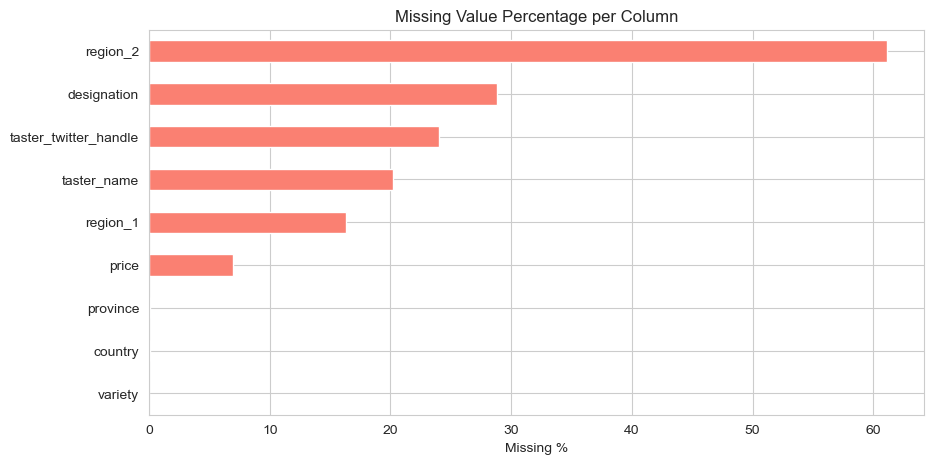

In [11]:
# Visualizing missing values
plt.figure(figsize=(10, 5))
missing_percent[missing_percent > 0].sort_values().plot(kind='barh', color='salmon')
plt.title("Missing Value Percentage per Column")
plt.xlabel("Missing %")
plt.show()

In [12]:
# Handling missing values — fill price with median
df['price'] = df['price'].fillna(df['price'].median())

# Drop rows where country is missing
df = df.dropna(subset=['country'])

print("Missing values after handling:")
df[['price', 'country']].isnull().sum()

Missing values after handling:


price      0
country    0
dtype: int64

---
## 6️⃣ Step 4 — Univariate Analysis

Analyzing one variable at a time.

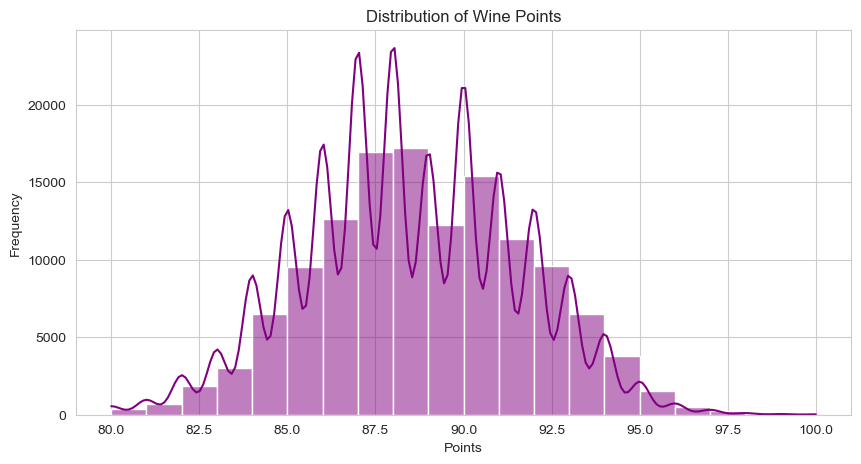

In [13]:
# Distribution of Points (Numerical)
plt.figure(figsize=(10, 5))
sns.histplot(df['points'], kde=True, color='purple', bins=20)
plt.title("Distribution of Wine Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()

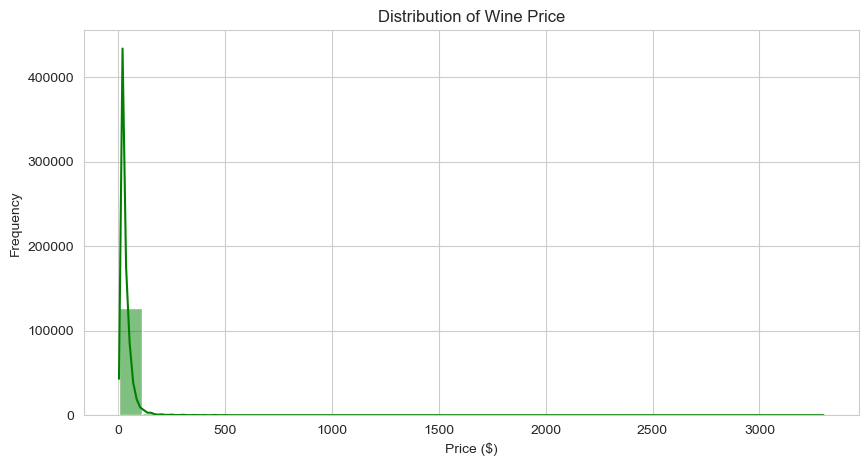

In [14]:
# Distribution of Price (Numerical)
plt.figure(figsize=(10, 5))
sns.histplot(df['price'], kde=True, color='green', bins=30)
plt.title("Distribution of Wine Price")
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.show()

C:\Users\aslam\AppData\Local\Temp\ipykernel_4384\614814594.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


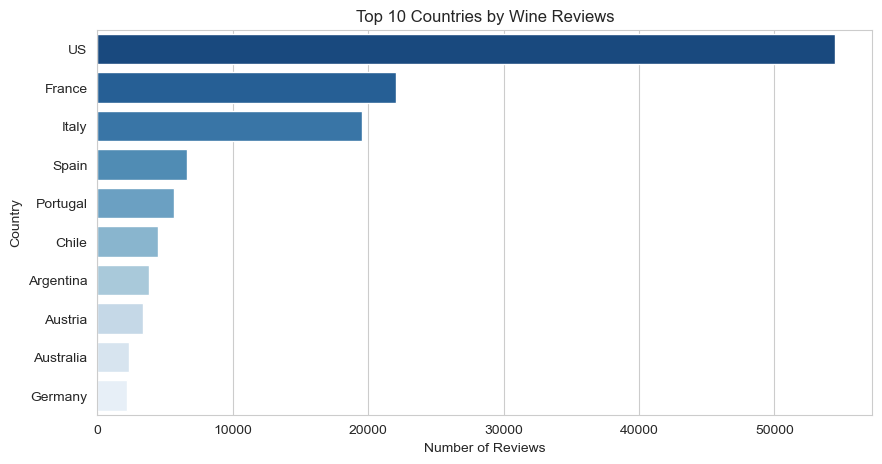

In [15]:
# Top 10 Countries by Review Count (Categorical)
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title("Top 10 Countries by Wine Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Country")
plt.show()

---
## 7️⃣ Step 5 — Bivariate Analysis

Analyzing the relationship between two variables.

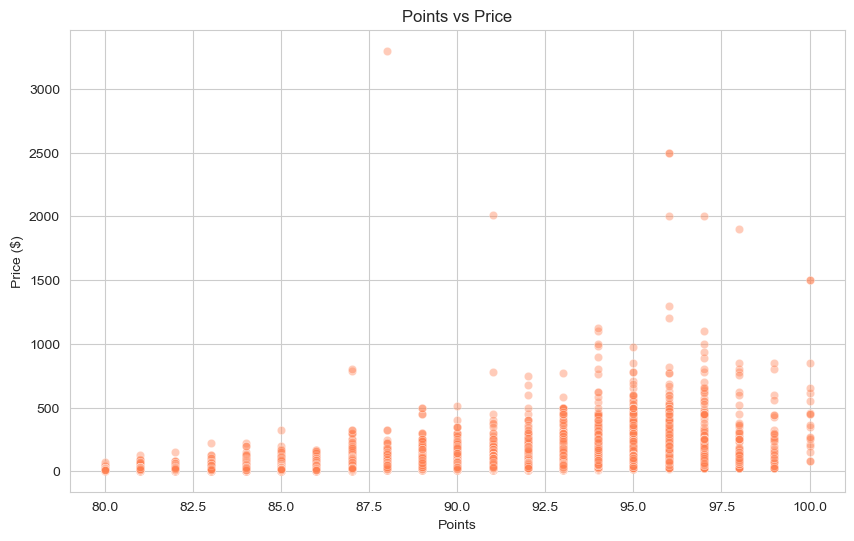

In [16]:
# Numerical vs Numerical — Points vs Price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='points', y='price', alpha=0.4, color='coral')
plt.title("Points vs Price")
plt.xlabel("Points")
plt.ylabel("Price ($)")
plt.show()

C:\Users\aslam\AppData\Local\Temp\ipykernel_4384\2976075688.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top5, x='country', y='points', palette='Set2')


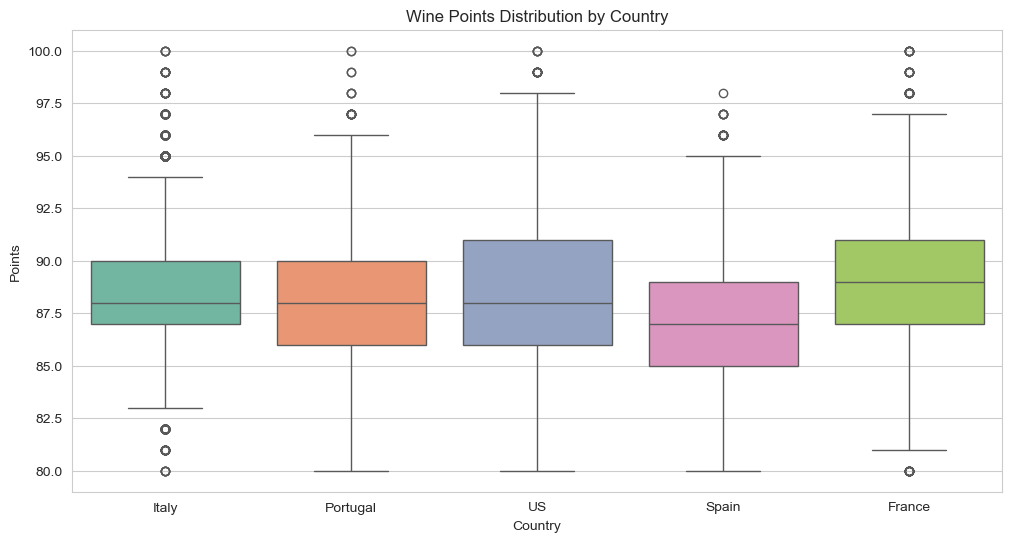

In [17]:
# Numerical vs Categorical — Points by Top 5 Countries
top5 = df['country'].value_counts().head(5).index
df_top5 = df[df['country'].isin(top5)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top5, x='country', y='points', palette='Set2')
plt.title("Wine Points Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Points")
plt.show()

C:\Users\aslam\AppData\Local\Temp\ipykernel_4384\1886507612.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.index, y=avg_price.values, palette='Set1')


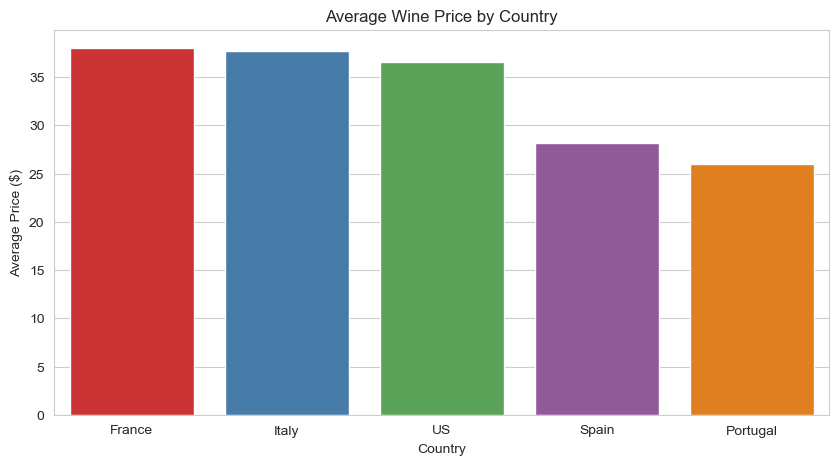

In [18]:
# Average Price by Country
avg_price = df_top5.groupby('country')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price.index, y=avg_price.values, palette='Set1')
plt.title("Average Wine Price by Country")
plt.xlabel("Country")
plt.ylabel("Average Price ($)")
plt.show()

---
## 8️⃣ Step 6 — Multivariate Analysis

Analyzing more than two variables at the same time.

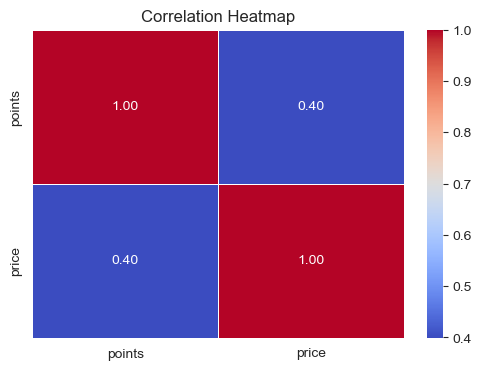

In [19]:
# Correlation Heatmap
corr = df[['points', 'price']].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

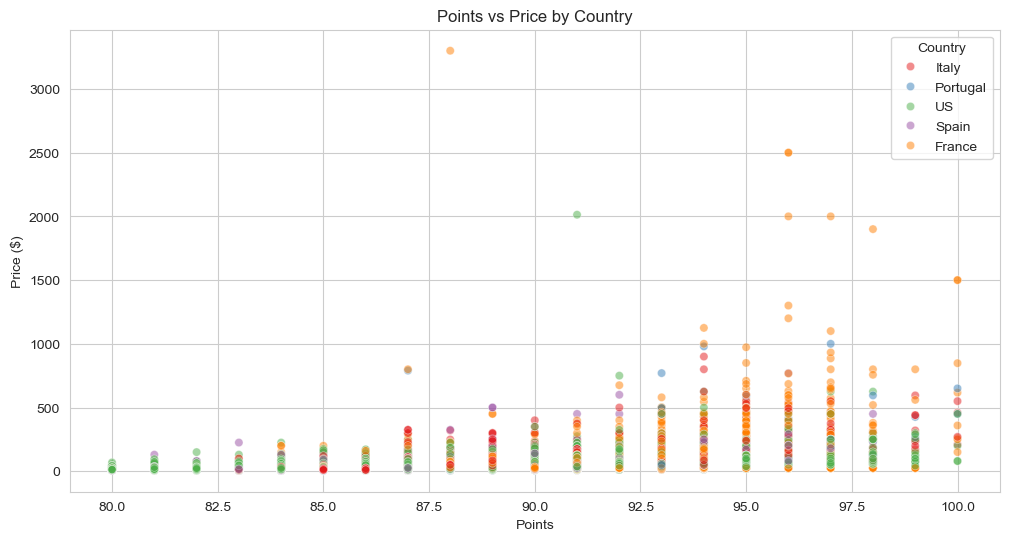

In [20]:
# Color-coded Scatter — Points vs Price by Country
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_top5, x='points', y='price', hue='country', alpha=0.5, palette='Set1')
plt.title("Points vs Price by Country")
plt.xlabel("Points")
plt.ylabel("Price ($)")
plt.legend(title='Country')
plt.show()

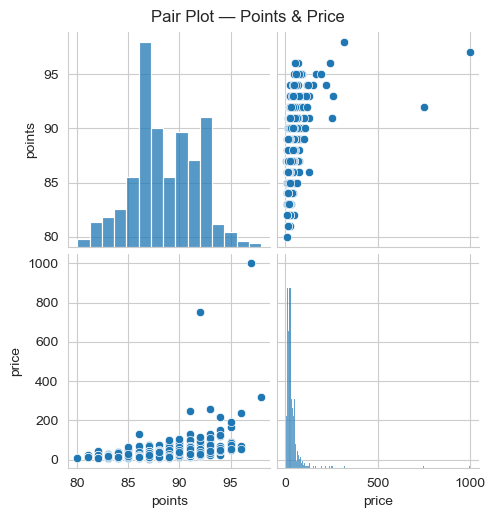

In [21]:
# Pair Plot — Full Overview
df_sample = df[['points', 'price']].dropna().sample(500, random_state=42)

sns.pairplot(df_sample)
plt.suptitle("Pair Plot — Points & Price", y=1.02)
plt.show()

---
## 9️⃣ Step 7 — Outlier Detection

Outliers are extreme values that can skew your analysis and model predictions.

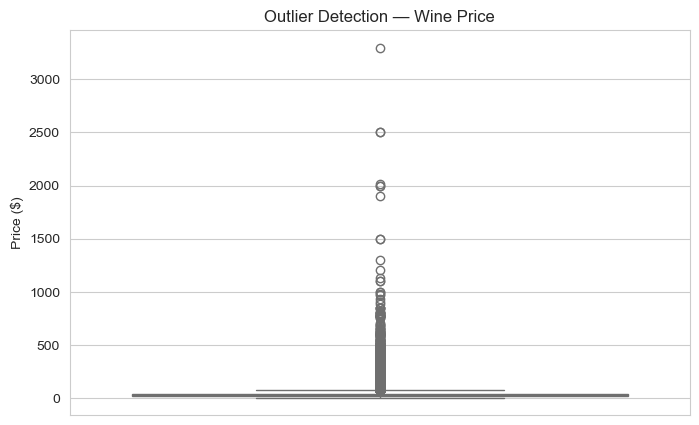

In [22]:
# Boxplot to detect outliers in Price
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['price'], color='skyblue')
plt.title("Outlier Detection — Wine Price")
plt.ylabel("Price ($)")
plt.show()

In [23]:
# IQR Method to detect outliers
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print(f"Q1: {Q1} | Q3: {Q3} | IQR: {IQR}")
print(f"Lower Bound: {lower} | Upper Bound: {upper}")
print(f"Total Outliers Found: {len(outliers)}")

Q1: 18.0 | Q3: 40.0 | IQR: 22.0
Lower Bound: -15.0 | Upper Bound: 73.0
Total Outliers Found: 9053


In [24]:
# Removing outliers
df_no_outliers = df[(df['price'] >= lower) & (df['price'] <= upper)]

print(f"Original Shape: {df.shape}")
print(f"After Removing Outliers: {df_no_outliers.shape}")

Original Shape: (129908, 13)
After Removing Outliers: (120855, 13)


---
## 🔟 When to Use What

| EDA Step | What to Use | Purpose |
|----------|-------------|---------|
| Understand structure | `shape`, `dtypes`, `describe()` | Know your data dimensions and types |
| Missing values | `isnull().sum()` + bar chart | Find and visualize gaps |
| Numerical distribution | `histplot`, `kdeplot` | Understand spread and shape |
| Categorical frequency | `value_counts()`, `barplot` | See which categories dominate |
| Num vs Num relationship | `scatterplot`, `regplot` | Find correlations |
| Num vs Cat relationship | `boxplot`, `violinplot` | Compare distributions by group |
| Correlations | `heatmap` | Spot linear relationships |
| Full overview | `pairplot` | Visualize all variables at once |
| Outlier detection | `boxplot`, IQR method | Find and remove extreme values |

---
## 🔑 Key Takeaways

→ Always start EDA with `shape`, `dtypes`, and `describe()` — know your data before touching it  
→ Missing values should be handled **before** any analysis or modeling  
→ Univariate analysis tells you **what** your data looks like  
→ Bivariate analysis tells you **how** variables relate to each other  
→ Multivariate analysis tells you the **full story**  
→ Outliers detected early save you from wrong model predictions later  
→ EDA is not a step — it is a **habit**

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 11 of 100 — Keep Learning, Keep Building 🚀*